# Experimentos de investigacion: robustez y explicabilidad

Este notebook fortalece el proyecto original. En vez de reportar solo un accuracy general, evalua cuatro dimensiones: comparacion contra baseline, robustez por SNR, aporte de features y generalizacion a canales no ideales.


In [1]:
try:
    from IPython.display import SVG, display
except Exception:
    class SVG(str):
        pass

    def display(value):
        print(str(value)[:1000])
import csv, json
from pathlib import Path

ROOT = Path.cwd()
RESEARCH_DIR = ROOT / "outputs" / "research"
summary = json.loads((RESEARCH_DIR / "research_summary.json").read_text(encoding="utf-8"))
print("Baseline DSP: 82.13%")
print("MLP IA: 98.01%")
print("Mejora absoluta: 15.88 puntos porcentuales")


Baseline DSP: 82.13%
MLP IA: 98.01%
Mejora absoluta: 15.88 puntos porcentuales


## 1. IA vs baseline DSP

El baseline usa los mismos rasgos DSP, pero clasifica con distancia minima al centroide de cada modulacion. Esto funciona como una referencia clasica simple: si la red neuronal no supera esto, la IA no esta aportando mucho.


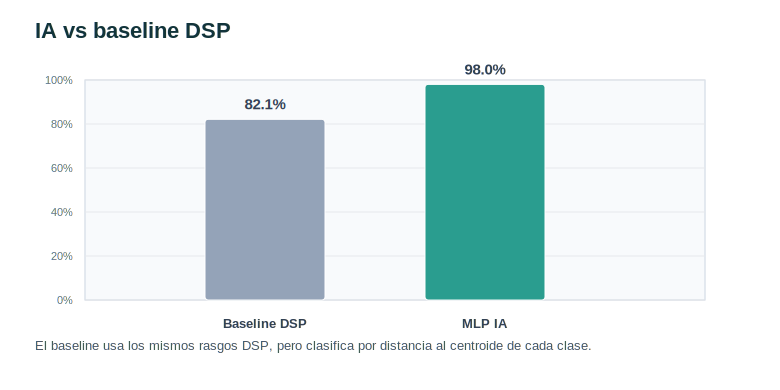

In [2]:
baseline_chart = '<svg xmlns="http://www.w3.org/2000/svg" width="780" height="390" viewBox="0 0 780 390" style="background:#ffffff"><title>IA vs baseline</title><text x="35.0" y="38.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">IA vs baseline DSP</text><rect x="85.0" y="80.0" width="620.0" height="220.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="85.0" y1="300.0" x2="705.0" y2="300.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="304.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="85.0" y1="256.0" x2="705.0" y2="256.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="260.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="85.0" y1="212.0" x2="705.0" y2="212.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="216.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="85.0" y1="168.0" x2="705.0" y2="168.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="172.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="85.0" y1="124.0" x2="705.0" y2="124.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="128.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="85.0" y1="80.0" x2="705.0" y2="80.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="84.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="205.0" y="119.3" width="120.0" height="180.7" rx="3" fill="#94A3B8" stroke="#FFFFFF"/><text x="265.0" y="109.3" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">82.1%</text><text x="265.0" y="328.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="middle" fill="#334155">Baseline DSP</text><rect x="425.0" y="84.4" width="120.0" height="215.6" rx="3" fill="#2A9D8F" stroke="#FFFFFF"/><text x="485.0" y="74.4" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">98.0%</text><text x="485.0" y="328.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="middle" fill="#334155">MLP IA</text><text x="35.0" y="350.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">El baseline usa los mismos rasgos DSP, pero clasifica por distancia al centroide de cada clase.</text></svg>'
display(SVG(baseline_chart))


## 2. Robustez por SNR

Esta prueba responde una pregunta clave: ¿desde que nivel de ruido el sistema empieza a ser confiable? El resultado inicial indica que el clasificador mejora claramente desde 5 dB y se vuelve casi perfecto desde 10 dB en el escenario simulado.


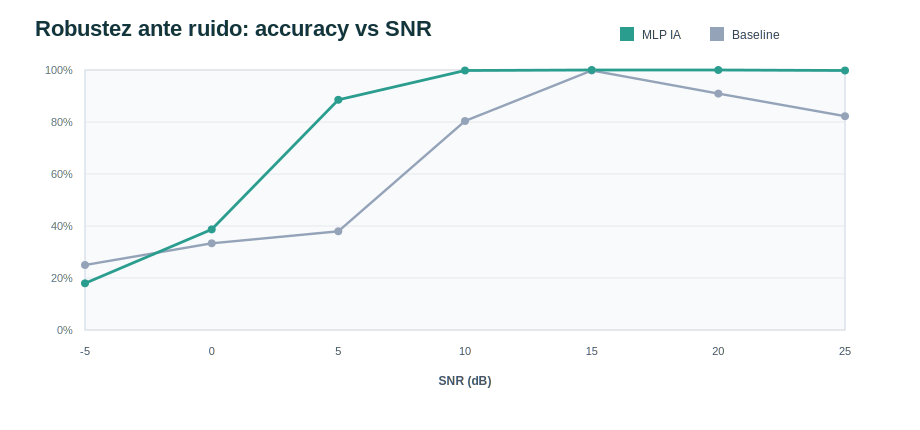

In [3]:
snr_chart = '<svg xmlns="http://www.w3.org/2000/svg" width="920" height="430" viewBox="0 0 920 430" style="background:#ffffff"><title>Accuracy vs SNR</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Robustez ante ruido: accuracy vs SNR</text><rect x="85.0" y="70.0" width="760.0" height="260.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="85.0" y1="330.0" x2="845.0" y2="330.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="334.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="85.0" y1="278.0" x2="845.0" y2="278.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="282.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="85.0" y1="226.0" x2="845.0" y2="226.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="230.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="85.0" y1="174.0" x2="845.0" y2="174.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="178.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="85.0" y1="122.0" x2="845.0" y2="122.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="126.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="85.0" y1="70.0" x2="845.0" y2="70.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="74.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><polyline points="85.0,265.0 211.7,243.3 338.3,231.3 465.0,121.0 591.7,70.5 718.3,93.6 845.0,116.2" fill="none" stroke="#94A3B8" stroke-width="2.4"/><polyline points="85.0,283.3 211.7,229.4 338.3,99.8 465.0,70.5 591.7,70.0 718.3,70.0 845.0,70.5" fill="none" stroke="#2A9D8F" stroke-width="2.8"/><circle cx="85.0" cy="265.0" r="4" fill="#94A3B8"/><circle cx="85.0" cy="283.3" r="4" fill="#2A9D8F"/><text x="85.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">-5</text><circle cx="211.7" cy="243.3" r="4" fill="#94A3B8"/><circle cx="211.7" cy="229.4" r="4" fill="#2A9D8F"/><text x="211.7" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">0</text><circle cx="338.3" cy="231.3" r="4" fill="#94A3B8"/><circle cx="338.3" cy="99.8" r="4" fill="#2A9D8F"/><text x="338.3" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">5</text><circle cx="465.0" cy="121.0" r="4" fill="#94A3B8"/><circle cx="465.0" cy="70.5" r="4" fill="#2A9D8F"/><text x="465.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">10</text><circle cx="591.7" cy="70.5" r="4" fill="#94A3B8"/><circle cx="591.7" cy="70.0" r="4" fill="#2A9D8F"/><text x="591.7" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">15</text><circle cx="718.3" cy="93.6" r="4" fill="#94A3B8"/><circle cx="718.3" cy="70.0" r="4" fill="#2A9D8F"/><text x="718.3" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">20</text><circle cx="845.0" cy="116.2" r="4" fill="#94A3B8"/><circle cx="845.0" cy="70.5" r="4" fill="#2A9D8F"/><text x="845.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">25</text><text x="465.0" y="385.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#475569">SNR (dB)</text><rect x="620.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="642.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="710.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="732.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text></svg>'
display(SVG(snr_chart))


## 3. Ablation study

El ablation study entrena modelos usando solo ciertos grupos de rasgos. Esto permite justificar que el DSP no es decorativo: algunos rasgos contienen mas informacion discriminante que otros.


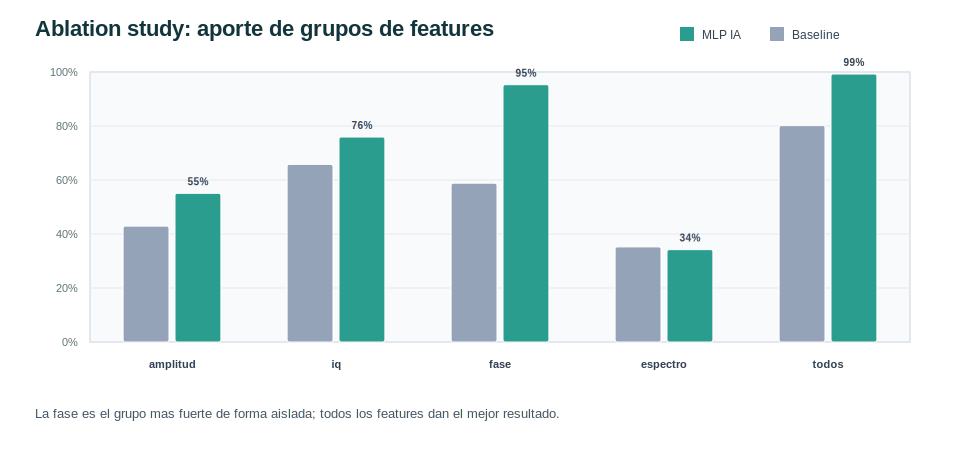

In [4]:
ablation_chart = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="470" viewBox="0 0 980 470" style="background:#ffffff"><title>Ablation study: aporte de grupos de features</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Ablation study: aporte de grupos de features</text><rect x="90.0" y="72.0" width="820.0" height="270.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="90.0" y1="342.0" x2="910.0" y2="342.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="346.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="90.0" y1="288.0" x2="910.0" y2="288.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="292.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="90.0" y1="234.0" x2="910.0" y2="234.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="238.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="90.0" y1="180.0" x2="910.0" y2="180.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="184.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="90.0" y1="126.0" x2="910.0" y2="126.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="130.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="90.0" y1="72.0" x2="910.0" y2="72.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="76.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="123.1" y="226.1" width="45.9" height="115.9" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="175.0" y="193.3" width="45.9" height="148.7" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="172.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">amplitud</text><text x="198.0" y="185.3" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">55%</text><rect x="287.1" y="164.4" width="45.9" height="177.6" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="339.0" y="137.0" width="45.9" height="205.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="336.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">iq</text><text x="362.0" y="129.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">76%</text><rect x="451.1" y="183.2" width="45.9" height="158.8" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="503.0" y="84.7" width="45.9" height="257.3" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="500.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">fase</text><text x="526.0" y="76.7" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">95%</text><rect x="615.1" y="246.9" width="45.9" height="95.1" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="667.0" y="249.6" width="45.9" height="92.4" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="664.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">espectro</text><text x="690.0" y="241.6" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">34%</text><rect x="779.1" y="125.6" width="45.9" height="216.4" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="831.0" y="74.0" width="45.9" height="268.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="828.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">todos</text><text x="854.0" y="66.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">99%</text><rect x="680.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="702.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="770.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="792.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text><text x="35.0" y="418.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">La fase es el grupo mas fuerte de forma aislada; todos los features dan el mejor resultado.</text></svg>'
display(SVG(ablation_chart))


## 4. Generalizacion a canales no ideales

El modelo se entrena en AWGN y se prueba en AWGN, Rayleigh y multipath. Esta es una prueba mas realista: si el canal cambia, el clasificador no deberia colapsar por completo.


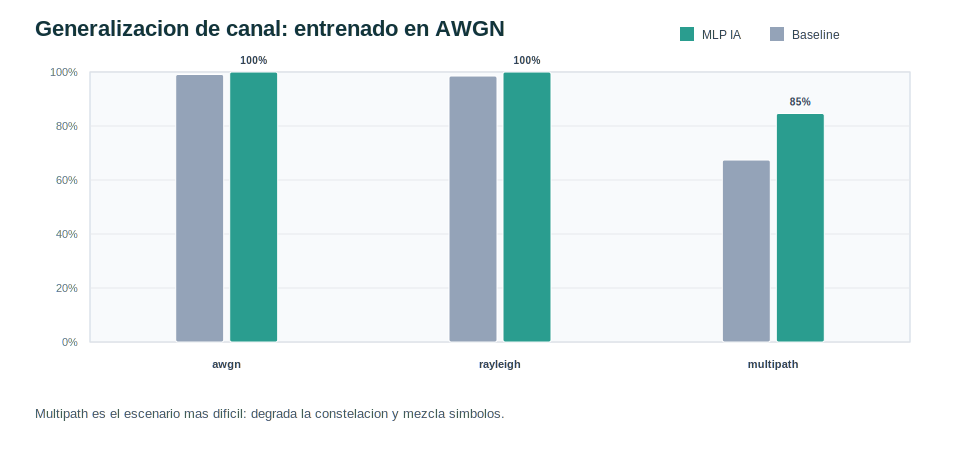

In [5]:
channel_chart = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="470" viewBox="0 0 980 470" style="background:#ffffff"><title>Generalizacion de canal: entrenado en AWGN</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Generalizacion de canal: entrenado en AWGN</text><rect x="90.0" y="72.0" width="820.0" height="270.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="90.0" y1="342.0" x2="910.0" y2="342.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="346.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="90.0" y1="288.0" x2="910.0" y2="288.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="292.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="90.0" y1="234.0" x2="910.0" y2="234.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="238.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="90.0" y1="180.0" x2="910.0" y2="180.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="184.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="90.0" y1="126.0" x2="910.0" y2="126.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="130.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="90.0" y1="72.0" x2="910.0" y2="72.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="76.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="175.7" y="74.5" width="48.0" height="267.5" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="229.7" y="72.0" width="48.0" height="270.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="226.7" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">awgn</text><text x="253.7" y="64.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">100%</text><rect x="449.0" y="76.0" width="48.0" height="266.0" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="503.0" y="72.0" width="48.0" height="270.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="500.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">rayleigh</text><text x="527.0" y="64.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">100%</text><rect x="722.3" y="160.0" width="48.0" height="182.0" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="776.3" y="113.5" width="48.0" height="228.5" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="773.3" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">multipath</text><text x="800.3" y="105.5" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">85%</text><rect x="680.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="702.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="770.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="792.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text><text x="35.0" y="418.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">Multipath es el escenario mas dificil: degrada la constelacion y mezcla simbolos.</text></svg>'
display(SVG(channel_chart))


## Conclusiones investigativas

- La IA mejora de forma clara frente al baseline DSP: 98.0% vs 82.1%.
- La robustez depende fuertemente del SNR; por debajo de 0 dB el problema se vuelve ambiguo.
- Los rasgos de fase son los mas informativos de forma aislada.
- Multipath es el canal mas desafiante y abre una linea natural para mejorar el proyecto.

Una formulacion fuerte del proyecto seria:

**Evaluacion de robustez y explicabilidad de un clasificador inteligente de modulaciones digitales basado en rasgos DSP bajo condiciones de canal no ideales.**


## Proximos pasos para nivel paper

- Repetir cada experimento con 5 semillas y reportar media/desviacion estandar.
- Agregar canal Rayleigh con fading variable en el tiempo.
- Incluir una CNN con espectrogramas si se instala PyTorch.
- Medir tiempo de inferencia y numero de parametros.
- Analizar casos fallidos con constelacion y espectro.
